In [315]:
import numpy as np
import pandas as pd
from scipy import stats
from bs4 import BeautifulSoup
import pingouin as pg
import seaborn as sns 
import matplotlib.pyplot as plt

In [316]:
df = pd.read_excel('anketa511686-2026-04-16.xlsx')

In [317]:
df = df.iloc[1:].reset_index(drop=True)

In [318]:
df['itime'].value_counts()

itime
16.04.2026    975
06.04.2026      1
09.04.2026      1
15.04.2026      1
Name: count, dtype: int64

In [319]:
df['itime'] = pd.to_datetime(df['itime'], dayfirst=True, errors='coerce')

df = df[df['itime'] == '2026-04-16']

In [320]:
cols = [f'CJ{i}' for i in range(1, 121)]

df = df[(df[cols] > 0).sum(axis=1) >= 4]

In [321]:
df

,status,invitation,relevance,lurker,recnum,code,testdata,itime,Q1,Q3a,...,date_19,date_20,date_21,Browser,BrowserVersion,OS,Device,Referer,Unsubscribed,Language
3,6,0,1,0,14,NaN,0,2026-04-16,1,5,...,16.04.2026 02:12:34,16.04.2026 02:14:07,16.04.2026 02:15:01,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 134.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
4,5,0,1,0,15,NaN,0,2026-04-16,1,5,...,16.04.2026 02:09:00,16.04.2026 02:09:42,NaN,Mozilla/5.0 (Linux; arm_64; Android 15; RMX393...,Chrome 0.0,Android,Phone,https://iframe-tasks.yandex/,0,Russian
6,5,0,1,0,18,NaN,0,2026-04-16,1,5,...,16.04.2026 02:20:04,16.04.2026 02:23:58,NaN,Mozilla/5.0 (Linux; Android 16; Redmi Note 14 ...,Chrome 135.0,Android,Phone,0,0,Russian
7,5,0,1,0,19,NaN,0,2026-04-16,1,5,...,16.04.2026 02:35:41,16.04.2026 02:38:46,NaN,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
8,5,0,1,0,21,NaN,0,2026-04-16,1,5,...,16.04.2026 03:13:24,16.04.2026 03:15:54,NaN,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 128.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,6,0,1,0,1317,NaN,0,2026-04-16,1,5,...,16.04.2026 14:41:53,16.04.2026 14:42:21,16.04.2026 14:43:14,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Chrome 0.0,Android,Phone,0,0,NaN
973,5,0,1,0,1320,NaN,0,2026-04-16,1,5,...,16.04.2026 14:58:51,16.04.2026 14:59:36,NaN,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,NaN
974,6,0,1,0,1321,NaN,0,2026-04-16,1,5,...,16.04.2026 14:55:40,16.04.2026 14:55:59,16.04.2026 14:56:20,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 128.0,Win10,PC,https://iframe-tasks.yandex/,0,NaN
976,6,0,1,0,1323,NaN,0,2026-04-16,1,5,...,16.04.2026 15:25:55,16.04.2026 15:26:48,16.04.2026 15:27:24,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Chrome 0.0,Android,Phone,0,0,NaN


In [322]:
df = df[
    (df['Q3a'] == 5) &
    (df['Q99g'] == 4) &
    (df['Q8j'] == 2)
]

In [323]:
df[df['Q42'] > 0]

,status,invitation,relevance,lurker,recnum,code,testdata,itime,Q1,Q3a,...,date_19,date_20,date_21,Browser,BrowserVersion,OS,Device,Referer,Unsubscribed,Language
11,6,0,1,0,25,NaN,0,2026-04-16,1,5,...,16.04.2026 04:42:29,16.04.2026 04:47:02,16.04.2026 04:47:43,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 128.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
14,6,0,1,0,29,NaN,0,2026-04-16,1,5,...,16.04.2026 11:00:12,16.04.2026 11:00:59,16.04.2026 11:01:32,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 109.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
15,6,0,1,0,30,NaN,0,2026-04-16,1,5,...,16.04.2026 11:03:45,16.04.2026 11:06:59,16.04.2026 11:08:14,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
18,6,0,1,0,33,NaN,0,2026-04-16,1,5,...,16.04.2026 10:59:54,16.04.2026 11:00:39,16.04.2026 11:00:52,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
19,6,0,1,0,34,NaN,0,2026-04-16,1,5,...,16.04.2026 11:02:30,16.04.2026 11:04:26,16.04.2026 11:05:24,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,6,0,1,0,1310,NaN,0,2026-04-16,1,5,...,16.04.2026 14:29:14,16.04.2026 14:30:59,16.04.2026 14:31:37,Mozilla/5.0 (Linux; arm_64; Android 13; RMX376...,Chrome 0.0,Android,Phone,0,0,NaN
971,6,0,1,0,1317,NaN,0,2026-04-16,1,5,...,16.04.2026 14:41:53,16.04.2026 14:42:21,16.04.2026 14:43:14,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Chrome 0.0,Android,Phone,0,0,NaN
974,6,0,1,0,1321,NaN,0,2026-04-16,1,5,...,16.04.2026 14:55:40,16.04.2026 14:55:59,16.04.2026 14:56:20,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 128.0,Win10,PC,https://iframe-tasks.yandex/,0,NaN
976,6,0,1,0,1323,NaN,0,2026-04-16,1,5,...,16.04.2026 15:25:55,16.04.2026 15:26:48,16.04.2026 15:27:24,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Chrome 0.0,Android,Phone,0,0,NaN


In [324]:
df['t_insert'] = pd.to_datetime(df['t_insert'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
df['t_edit']   = pd.to_datetime(df['t_edit'],   format='%d.%m.%Y %H:%M:%S', errors='coerce')

/var/folders/zb/3wk8z5297xq32rxjjztvzgkh0000gn/T/ipykernel_79695/3171961957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['t_insert'] = pd.to_datetime(df['t_insert'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
/var/folders/zb/3wk8z5297xq32rxjjztvzgkh0000gn/T/ipykernel_79695/3171961957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['t_edit']   = pd.to_datetime(df['t_edit'],   format='%d.%m.%Y %H:%M:%S', errors='coerce')


In [325]:
cols = ['Q40', 'Q41a', 'Q41b', 'Q42']

df = df[(df[cols] >= 0).all(axis=1)]

In [326]:
df

,status,invitation,relevance,lurker,recnum,code,testdata,itime,Q1,Q3a,...,date_19,date_20,date_21,Browser,BrowserVersion,OS,Device,Referer,Unsubscribed,Language
11,6,0,1,0,25,NaN,0,2026-04-16,1,5,...,16.04.2026 04:42:29,16.04.2026 04:47:02,16.04.2026 04:47:43,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 128.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
14,6,0,1,0,29,NaN,0,2026-04-16,1,5,...,16.04.2026 11:00:12,16.04.2026 11:00:59,16.04.2026 11:01:32,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 109.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
15,6,0,1,0,30,NaN,0,2026-04-16,1,5,...,16.04.2026 11:03:45,16.04.2026 11:06:59,16.04.2026 11:08:14,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
18,6,0,1,0,33,NaN,0,2026-04-16,1,5,...,16.04.2026 10:59:54,16.04.2026 11:00:39,16.04.2026 11:00:52,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
19,6,0,1,0,34,NaN,0,2026-04-16,1,5,...,16.04.2026 11:02:30,16.04.2026 11:04:26,16.04.2026 11:05:24,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 0.0,Win10,PC,https://iframe-tasks.yandex/,0,Russian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,6,0,1,0,1310,NaN,0,2026-04-16,1,5,...,16.04.2026 14:29:14,16.04.2026 14:30:59,16.04.2026 14:31:37,Mozilla/5.0 (Linux; arm_64; Android 13; RMX376...,Chrome 0.0,Android,Phone,0,0,NaN
971,6,0,1,0,1317,NaN,0,2026-04-16,1,5,...,16.04.2026 14:41:53,16.04.2026 14:42:21,16.04.2026 14:43:14,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Chrome 0.0,Android,Phone,0,0,NaN
974,6,0,1,0,1321,NaN,0,2026-04-16,1,5,...,16.04.2026 14:55:40,16.04.2026 14:55:59,16.04.2026 14:56:20,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Chrome 128.0,Win10,PC,https://iframe-tasks.yandex/,0,NaN
976,6,0,1,0,1323,NaN,0,2026-04-16,1,5,...,16.04.2026 15:25:55,16.04.2026 15:26:48,16.04.2026 15:27:24,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Chrome 0.0,Android,Phone,0,0,NaN


In [327]:
df['Q38'].value_counts()

Q38
2    234
1    196
3      1
Name: count, dtype: int64

In [328]:
df = df[df['Q39'] == 1]

In [329]:
df['Age'] = df['Q37'].astype(int)
df = df[df['Q38'].isin([1, 2])]
df['Female'] = (df['Q38'] == 2).astype(int)
df['Education_Level'] = df['Q40'].astype(int)
df['Political_Interest'] = df['Q41a'].astype(int)
df['Political_Competence'] = df['Q41b'].astype(int)
df['Income_Level'] = df['Q42'].astype(int)

/var/folders/zb/3wk8z5297xq32rxjjztvzgkh0000gn/T/ipykernel_79695/2826155527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Q37'].astype(int)


In [416]:
vars_dict = {

    'Age': 'Age',

    'Female': 'Female (1 = Yes)',

}

df_desc = df[list(vars_dict.keys())].copy()

df_desc = df_desc.rename(columns=vars_dict)

In [417]:
desc_table = df_desc.describe().T

# Keep only relevant stats

desc_table = desc_table[['count', 'mean', 'std', 'min', 'max']]

# Rename for presentation

desc_table.columns = ['N', 'Mean', 'Std. Dev.', 'Min', 'Max']

# Round nicely

desc_table = desc_table.round(3)

In [424]:
print(desc_table)

                      N    Mean  Std. Dev.   Min   Max
Age               429.0  35.678      9.955  18.0  66.0
Female (1 = Yes)  429.0   0.545      0.499   0.0   1.0


In [421]:
education_map = {
    1: "Primary education or less",
    2: "Secondary education (school)",
    3: "Vocational secondary education",
    4: "Incomplete higher education",
    5: "Higher education"
}
income_map = {
    1: "Not enough money even for food",
    2: "Enough for food, but clothing is difficult",
    3: "Enough for food and clothing, but durables are difficult",
    4: "Can afford durables, but not real estate",
    5: "Can afford everything, including real estate"
}

In [422]:
df['Education_Label'] = df['Education_Level'].map(education_map)
df['Income_Label'] = df['Income_Level'].map(income_map)

In [423]:
# Education
edu_counts = df['Education_Label'].value_counts()
edu_props = df['Education_Label'].value_counts(normalize=True)

edu_table = pd.DataFrame({
    'Count': edu_counts,
    'Share': edu_props
})

# Income
inc_counts = df['Income_Label'].value_counts()
inc_props = df['Income_Label'].value_counts(normalize=True)

inc_table = pd.DataFrame({
    'Count': inc_counts,
    'Share': inc_props
})

edu_order = list(education_map.values())

inc_order = list(income_map.values())

edu_table = edu_table.reindex(edu_order)

inc_table = inc_table.reindex(inc_order)
print(edu_table)
print(inc_table)

                                Count     Share
Education_Label                                
Primary education or less         NaN       NaN
Secondary education (school)     32.0  0.074592
Vocational secondary education  138.0  0.321678
Incomplete higher education      38.0  0.088578
Higher education                221.0  0.515152
                                                    Count     Share
Income_Label                                                       
Not enough money even for food                         19  0.044289
Enough for food, but clothing is difficult             62  0.144522
Enough for food and clothing, but durables are ...    199  0.463869
Can afford durables, but not real estate              142  0.331002
Can afford everything, including real estate            7  0.016317


In [330]:
cols = [f'CJ{i}' for i in range(1, 121)]

In [331]:
df['cj_positive_count'] = (df[cols] > 0).sum(axis=1)

In [332]:
df['cj_positive_count'].value_counts().sort_index()

cj_positive_count
4    429
Name: count, dtype: int64

In [333]:
with open("full_survey_upd.html", "r", encoding="utf-8") as f:
    html = f.read()

soup = BeautifulSoup(html, "html.parser")


In [334]:
divs = soup.find_all("div", class_="variable_name")

In [335]:
conjoints = divs[41:161]


In [336]:
conjoints[0].find('i')

<i>C1E1F1S2/C1E1F1S1</i>

In [337]:
conjoints[0].text

'CJ1 - C1E1F1S2/C1E1F1S1'

In [338]:
var_to_encod = [(conjoint.text.split(' - ')[0].strip(), conjoint.find('i').text.strip()) for conjoint in conjoints]    

In [339]:
var_to_encod

[('CJ1', 'C1E1F1S2/C1E1F1S1'),
 ('CJ2', 'C1E1F1S1/C1E1F2S1'),
 ('CJ3', 'C1E1F1S1/C1E1F2S2'),
 ('CJ4', 'C1E1F1S1/C1E2F1S1'),
 ('CJ5', 'C1E2F1S2/C1E1F1S1'),
 ('CJ6', 'C1E2F2S1/C1E1F1S1'),
 ('CJ7', 'C1E2F2S2/C1E1F1S1'),
 ('CJ8', 'C1E1F1S1/C2E1F1S1'),
 ('CJ9', 'C1E1F1S1/C2E1F1S2'),
 ('CJ10', 'C1E1F1S1/C2E1F2S1'),
 ('CJ11', 'C1E1F1S1/C2E1F2S2'),
 ('CJ12', 'C2E2F1S1/C1E1F1S1'),
 ('CJ13', 'C1E1F1S1/C2E2F1S2'),
 ('CJ14', 'C1E1F1S1/C2E2F2S1'),
 ('CJ15', 'C2E2F2S2/C1E1F1S1'),
 ('CJ16', 'C1E1F2S1/C1E1F1S2'),
 ('CJ17', 'C1E1F1S2/C1E1F2S2'),
 ('CJ18', 'C1E2F1S1/C1E1F1S2'),
 ('CJ19', 'C1E2F1S2/C1E1F1S2'),
 ('CJ20', 'C1E1F1S2/C1E2F2S1'),
 ('CJ21', 'C1E2F2S2/C1E1F1S2'),
 ('CJ22', 'C2E1F1S1/C1E1F1S2'),
 ('CJ23', 'C1E1F1S2/C2E1F1S2'),
 ('CJ24', 'C1E1F1S2/C2E1F2S1'),
 ('CJ25', 'C2E1F2S2/C1E1F1S2'),
 ('CJ26', 'C1E1F1S2/C2E2F1S1'),
 ('CJ27', 'C1E1F1S2/C2E2F1S2'),
 ('CJ28', 'C1E1F1S2/C2E2F2S1'),
 ('CJ29', 'C2E2F2S2/C1E1F1S2'),
 ('CJ30', 'C1E1F2S2/C1E1F2S1'),
 ('CJ31', 'C1E2F1S1/C1E1F2S1'),
 ('CJ32', 'C1E2F1

In [340]:
df.columns.get_loc('CJ1')

178

In [341]:
df.columns.get_loc('CJ120')

297

In [342]:
df['CJ1']

11     -2
14     -2
15     -2
18     -2
19     -2
       ..
968    -2
971    -2
974    -2
976    -2
977    -2
Name: CJ1, Length: 429, dtype: object

In [343]:
cols_to_drop = [
    'Q17a','Q17b','Q17c','Q17d',
    'Q18a','Q18b','Q18c','Q18d','Q18e','Q18f','Q18g','Q18h','Q18i',
    'Q20a','Q20b','Q20c','Q20d',
    'Q21a','Q21b','Q21c','Q21d','Q21e','Q21f','Q21g','Q21h','Q21i',
    'Q23a','Q23b','Q23c','Q23d',
    'Q24a','Q24b','Q24c','Q24d','Q24e','Q24f','Q24g','Q24h','Q24i',
    'Q26a','Q26b','Q26c','Q26d',
    'Q27a','Q27b','Q27c','Q27d','Q27e','Q27f','Q27g','Q27h','Q27i',
    'Q29a','Q29b','Q29c','Q29d',
    'Q30a','Q30b','Q30c','Q30d','Q30e','Q30f','Q30g','Q30h','Q30i',
    'Q32a','Q32b','Q32c','Q32d',
    'Q33a','Q33b','Q33c','Q33d','Q33e','Q33f','Q33g','Q33h','Q33i',
    'Q35a','Q35b','Q35c','Q35d',
    'Q36a','Q36b','Q36c','Q36d','Q36e','Q36f','Q36g','Q36h','Q36i'
]

df = df.drop(columns=cols_to_drop)

In [344]:
cols = ['Q6_2a', 'Q6_2b', 'Q6_2c']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [345]:
alpha, ci = pg.cronbach_alpha(data=df[['Q6_2a', 'Q6_2b', 'Q6_2c']])

print(alpha)

print(ci)

0.9331161838769879
[0.921 0.943]


In [346]:
df['Political_Trust'] = df[['Q6_2a', 'Q6_2b', 'Q6_2c']].mean(axis=1)

In [347]:
df['President_Trust'] = df['Q6_2c']

In [348]:
df['President_Trust'].describe()

count    429.000000
mean       3.512821
std        1.416838
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: President_Trust, dtype: float64

In [349]:
df['President_Trust'].value_counts()

President_Trust
5    135
4    119
3     78
1     72
2     25
Name: count, dtype: int64

In [350]:
df['Trust_bin'] = pd.cut(
    df['President_Trust'],
    bins=[0, 3, 4, 5],
    labels=['low', 'mid', 'high']
)

In [351]:
df[["Q99a", "Q99b", "Q99c", "Q99d", "Q99e", "Q99f"]] = df[["Q99a", "Q99b", "Q99c", "Q99d", "Q99e", "Q99f"]].apply(pd.to_numeric, errors='coerce')

In [352]:
alpha = pg.cronbach_alpha(df[["Q99a", "Q99b", "Q99c", "Q99d", "Q99e", "Q99f"]])

print(alpha)

(np.float64(0.9093025487988968), array([0.895, 0.922]))


In [353]:
df["Political_Self_Efficacy"] = df[["Q99a", "Q99b", "Q99c", "Q99d", "Q99e", "Q99f"]].mean(axis=1)

In [354]:
df[["Q8a", "Q8b", "Q8c", "Q8d", "Q8e", "Q8f", "Q8g", "Q8h", "Q8i"]] = df[["Q8a", "Q8b", "Q8c", "Q8d", "Q8e", "Q8f", "Q8g", "Q8h", "Q8i"]].apply(pd.to_numeric, errors='coerce')

In [355]:
alpha = pg.cronbach_alpha(df[["Q8a", "Q8b", "Q8c", "Q8d", "Q8e", "Q8f", "Q8g", "Q8h", "Q8i"]])

print(alpha)

(np.float64(0.9277775968090837), array([0.917, 0.938]))


In [426]:
df['Authoritarianism'].mean()

np.float64(3.1919191919191916)

In [428]:
df["Authoritarianism"].std(ddof = 1)

0.9701779562484596

In [430]:
df['President_Trust'].mean()

np.float64(3.5128205128205128)

In [431]:
df['President_Trust'].std()

1.4168375730348535

In [356]:
df['Authoritarianism'] = df[["Q8a", "Q8b", "Q8c", "Q8d", "Q8e", "Q8f", "Q8g", "Q8h", "Q8i"]].mean(axis=1)

In [357]:
df['Authoritarianism'].quantile([0.25, 0.5, 0.75])

0.25    2.777778
0.50    3.333333
0.75    3.888889
Name: Authoritarianism, dtype: float64

In [358]:
df['Authoritarianism'].describe()

count    429.000000
mean       3.191919
std        0.970178
min        1.000000
25%        2.777778
50%        3.333333
75%        3.888889
max        5.000000
Name: Authoritarianism, dtype: float64

In [434]:
df['Strong_Leader'].describe()

count    429.000000
mean       3.179487
std        1.177257
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Strong_Leader, dtype: float64

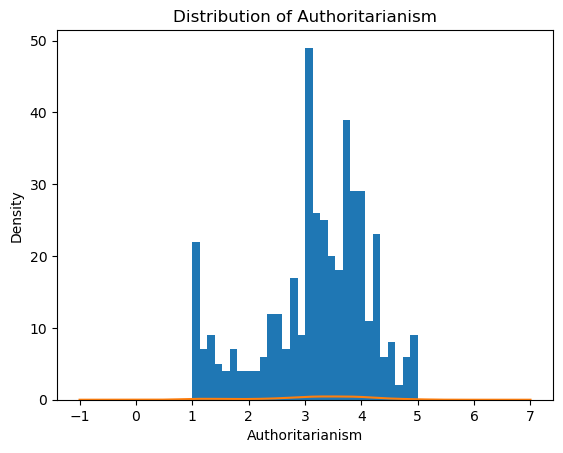

In [360]:
plt.figure()

df['Authoritarianism'].hist(bins=30)

df['Authoritarianism'].plot(kind='density')

plt.xlabel('Authoritarianism')

plt.ylabel('Density')

plt.title('Distribution of Authoritarianism')

plt.show()

In [361]:
df[["Q9a", "Q9b", "Q9c", "Q9d"]] = df[["Q9a", "Q9b", "Q9c", "Q9d"]].apply(pd.to_numeric, errors='coerce')

In [362]:
df[['Q9a_rev', 'Q9b_rev']] = 6 - df[['Q9a', 'Q9b']]
df[['Q9c_rev', 'Q9d_rev']] = 6 - df[['Q9c', 'Q9d']]

In [363]:
alpha_1 = pg.cronbach_alpha(df[["Q9a_rev", "Q9b_rev"]])
alpha_2 = pg.cronbach_alpha(df[["Q9c", "Q9d"]])
print(alpha_1)
print(alpha_2)

(np.float64(0.8115478422307567), array([0.772, 0.844]))
(np.float64(0.7531469177133603), array([0.702, 0.796]))


In [364]:
pg.cronbach_alpha(df[['Q9a', 'Q9b','Q9c_rev', 'Q9d_rev']])

(np.float64(0.7499093100956694), array([0.709, 0.786]))

In [365]:
pg.cronbach_alpha(df[["Q9a_rev", "Q9b_rev", "Q9c", "Q9d"]])

(np.float64(0.7499093100956694), array([0.709, 0.786]))

In [366]:
df['Nat_Interests_v_Ind_Rights'] = df[['Q9a', 'Q9b','Q9c_rev', 'Q9d_rev']].mean(axis=1)

In [367]:
df['Nat_Interests_v_Ind_Rights'].describe()

count    429.000000
mean       2.594988
std        0.830658
min        1.000000
25%        2.000000
50%        2.750000
75%        3.000000
max        5.000000
Name: Nat_Interests_v_Ind_Rights, dtype: float64

In [369]:

from semopy import Model

model_desc = """
F1 =~ Q9a + Q9b
F2 =~ Q9c + Q9d
"""

model = Model(model_desc)
model.fit(df)

print(model.inspect())

   lval  op rval  Estimate  Std. Err   z-value   p-value
0   Q9a   ~   F1  1.000000         -         -         -
1   Q9b   ~   F1  1.144970  0.120828  9.476061       0.0
2   Q9c   ~   F2  1.000000         -         -         -
3   Q9d   ~   F2  1.420943  0.182617  7.780983       0.0
4    F1  ~~   F1  0.846313  0.119675  7.071757       0.0
5    F2  ~~   F2  0.421133  0.072073  5.843132       0.0
6    F2  ~~   F1 -0.293100  0.052811 -5.550008       0.0
7   Q9a  ~~  Q9a  0.539605  0.089902  6.002135       0.0
8   Q9b  ~~  Q9b  0.342779  0.110024  3.115491  0.001836
9   Q9c  ~~  Q9c  0.482919  0.059655  8.095207       0.0
10  Q9d  ~~  Q9d  0.227037  0.101566  2.235352  0.025394


In [370]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[["Q9a", "Q9b", "Q9c", "Q9d"]].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(pca.components_)

[0.57245951 0.25153056]
[[ 0.50906477  0.52087814 -0.46320826 -0.50495261]
 [ 0.4958546   0.46674317  0.57384681  0.45494931]]


In [371]:
r_ab = df["Q9a"].corr(df["Q9b"])
r_cd = df["Q9c"].corr(df["Q9d"])

print(r_ab, r_cd)

0.6830478068380967 0.6063651059026022


In [372]:
from scipy.stats import pearsonr

r_ab, p_ab = pearsonr(df["Q9a"], df["Q9b"])

r_cd, p_cd = pearsonr(df["Q9c"], df["Q9d"])

print("r_ab:", r_ab, "p:", p_ab)

print("r_cd:", r_cd, "p:", p_cd)

r_ab: 0.6830478068380965 p: 3.0523295323985115e-60
r_cd: 0.606365105902601 p: 2.0056030481390912e-44


In [373]:
from scipy.stats import spearmanr

rho_ab, p_ab = spearmanr(df["Q9a"], df["Q9b"])

rho_cd, p_cd = spearmanr(df["Q9c"], df["Q9d"])
print(rho_ab, p_ab)
print(rho_cd, p_cd)

0.6633544841439655 9.88792182449049e-56
0.6187327389803287 1.108530579489644e-46


In [374]:
df["National_Interest"] = df[["Q9a", "Q9b"]].mean(axis=1)

df["Ind_Rights"] = df[["Q9c", "Q9d"]].mean(axis=1)

In [375]:
df['Strong_Leader'] = df['Q10a'].astype(int)
df['Democracy_Rule'] = df['Q10c'].astype(int)

In [376]:
mapping = {
    "Q11a": "Television_Frequency",
    "Q11b": "Internet_Frequency",
    "Q11c": "Social_Media_Frequency",
    "Q11d": "Messengers_Frequency",
    "Q11e": "Radio_Frequency",
    "Q11f": "Interpersonal_Communication_Frequency",
    "Q11g": "Newspapers_Frequency",
    "Q11h": "Magazines_Frequency"
}
for old, new in mapping.items():

    df[new] = pd.to_numeric(df[old], errors="coerce")

In [377]:
for new in mapping.values():

    df[new.replace("_Frequency", "_never")] = df[new].apply(

        lambda x: 1 if x == 1 else (0 if pd.notna(x) else None)

    )

In [379]:
mapping_q12 = {

    "Q12a": "Television",

    "Q12b": "Internet_Trust",

    "Q12c": "Social_Media",

    "Q12d": "Messengers",

    "Q12e": "Radio",

    "Q12f": "Interpersonal_Communication",

    "Q12g": "Newspapers",

    "Q12h": "Magazines"

}

for old, base in mapping_q12.items():

    

    # raw numeric version

    df[f"{base}_Trust"] = pd.to_numeric(df[old], errors="coerce")

    

    # use indicator (1 = uses, 0 = does not use)

    df[f"{base}_Use"] = (df[f"{base}_Trust"] != 6).astype(int)

    

    # trust among users (non-users → NaN)

    df[f"{base}_Trust_Clean"] = df[f"{base}_Trust"].replace(6, np.nan)

    

    # filled version to avoid dropping observations

    df[f"{base}_Trust_Filled"] = df[f"{base}_Trust_Clean"].fillna(0)

In [380]:
for c in df.columns:
    print(c)

status
invitation
relevance
lurker
recnum
code
testdata
itime
Q1
Q3a
Q5a
Q5b
Q5c
Q5d
Q5e
Q5f
Q6a
Q6b
Q6c
Q6d
Q6e
Q6f
Q6g
Q6h
Q7a
Q7b
Q7c
Q7d
Q7e
Q7f
Q7g
Q6_2a
Q6_2b
Q6_2c
Q99a
Q99b
Q99c
Q99d
Q99e
Q99f
Q99g
Q8a
Q8b
Q8c
Q8d
Q8e
Q8f
Q8g
Q8h
Q8i
Q8j
Q9a
Q9b
Q9c
Q9d
Q10a
Q10b
Q10c
Q11a
Q11b
Q11c
Q11d
Q11e
Q11f
Q11g
Q11h
Q12a
Q12b
Q12c
Q12d
Q12e
Q12f
Q12g
Q12h
Q14a
Q14b
Q14c
Q14d
Q15a
Q15b
Q15c
Q15d
Q15e
Q15f
Q15g
Q15h
Q15i
CJ1
CJ2
CJ3
CJ4
CJ5
CJ6
CJ7
CJ8
CJ9
CJ10
CJ11
CJ12
CJ13
CJ14
CJ15
CJ16
CJ17
CJ18
CJ19
CJ20
CJ21
CJ22
CJ23
CJ24
CJ25
CJ26
CJ27
CJ28
CJ29
CJ30
CJ31
CJ32
CJ33
CJ34
CJ35
CJ36
CJ37
CJ38
CJ39
CJ40
CJ41
CJ42
CJ43
CJ44
CJ45
CJ46
CJ47
CJ48
CJ49
CJ50
CJ51
CJ52
CJ53
CJ54
CJ55
CJ56
CJ57
CJ58
CJ59
CJ60
CJ61
CJ62
CJ63
CJ64
CJ65
CJ66
CJ67
CJ68
CJ69
CJ70
CJ71
CJ72
CJ73
CJ74
CJ75
CJ76
CJ77
CJ78
CJ79
CJ80
CJ81
CJ82
CJ83
CJ84
CJ85
CJ86
CJ87
CJ88
CJ89
CJ90
CJ91
CJ92
CJ93
CJ94
CJ95
CJ96
CJ97
CJ98
CJ99
CJ100
CJ101
CJ102
CJ103
CJ104
CJ105
CJ106
CJ107
CJ108
CJ109
CJ110
CJ111
CJ112
CJ113
CJ114
CJ

In [381]:
(df['Television_never'] != df['Television_Use']).sum()

np.int64(319)

In [382]:
vars_to_center = [

    # political moderators
    'President_Trust',
    'Authoritarianism',
    'Nat_Interests_v_Ind_Rights',
    'Strong_Leader',
    'Democracy_Rule',

    # media frequency
    'Television_Frequency',
    'Internet_Frequency',
    'Social_Media_Frequency',
    'Messengers_Frequency',
    'Radio_Frequency',
    'Interpersonal_Communication_Frequency',
    'Newspapers_Frequency',
    'Magazines_Frequency',

    # media trust (clean versions only)
    'Television_Trust_Clean',
    'Internet_Trust_Trust_Clean',  # consider renaming
    'Social_Media_Trust_Clean',
    'Messengers_Trust_Clean',
    'Radio_Trust_Clean',
    'Interpersonal_Communication_Trust_Clean',
    'Newspapers_Trust_Clean',
    'Magazines_Trust_Clean'
]

for var in vars_to_center:

    df[f'{var}_c'] = df[var] - df[var].mean()

/var/folders/zb/3wk8z5297xq32rxjjztvzgkh0000gn/T/ipykernel_79695/3752498199.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{var}_c'] = df[var] - df[var].mean()
/var/folders/zb/3wk8z5297xq32rxjjztvzgkh0000gn/T/ipykernel_79695/3752498199.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{var}_c'] = df[var] - df[var].mean()
/var/folders/zb/3wk8z5297xq32rxjjztvzgkh0000gn/T/ipykernel_79695/3752498199.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

In [383]:
# 0. Create respondent id from index if you have not done it yet
df = df.reset_index().rename(columns={'index': 'respondent_id'})

# 1. Conjoint columns
cj_cols = [f'CJ{i}' for i in range(1, 121)]

# 2. All non-conjoint columns
controls = [c for c in df.columns if c not in cj_cols]

# 3. Wide -> long
long_df = df.melt(
    id_vars=controls,
    value_vars=cj_cols,
    var_name='cj_var',
    value_name='pair_value'
)

# 4. Make sure pair_value is numeric
long_df['pair_value'] = pd.to_numeric(long_df['pair_value'], errors='coerce')

# 5. Keep only observed conjoint tasks
long_df = long_df[long_df['pair_value'] > 0].copy()

# 6. Sort and create task number within respondent
long_df = long_df.sort_values(['respondent_id', 'cj_var']).copy()
long_df['task_num'] = long_df.groupby('respondent_id').cumcount() + 1

# 7. Reorder columns
front_cols = ['respondent_id', 'task_num', 'cj_var', 'pair_value']
other_cols = [c for c in long_df.columns if c not in front_cols]
long_df = long_df[front_cols + other_cols]

# 8. Reset index
long_df = long_df.reset_index(drop=True)

# 9. Check: should be 4 rows per respondent
rows_per_respondent = long_df.groupby('respondent_id').size()
print(rows_per_respondent.value_counts().sort_index())

bad_ids = rows_per_respondent[rows_per_respondent != 4]
print("Number of respondents without exactly 4 rows:", len(bad_ids))

4    429
Name: count, dtype: int64
Number of respondents without exactly 4 rows: 0


In [384]:
long_df['cj_var'].value_counts()

cj_var
CJ93     26
CJ109    26
CJ97     22
CJ89     21
CJ63     21
         ..
CJ14      8
CJ83      8
CJ78      8
CJ105     7
CJ21      7
Name: count, Length: 120, dtype: int64

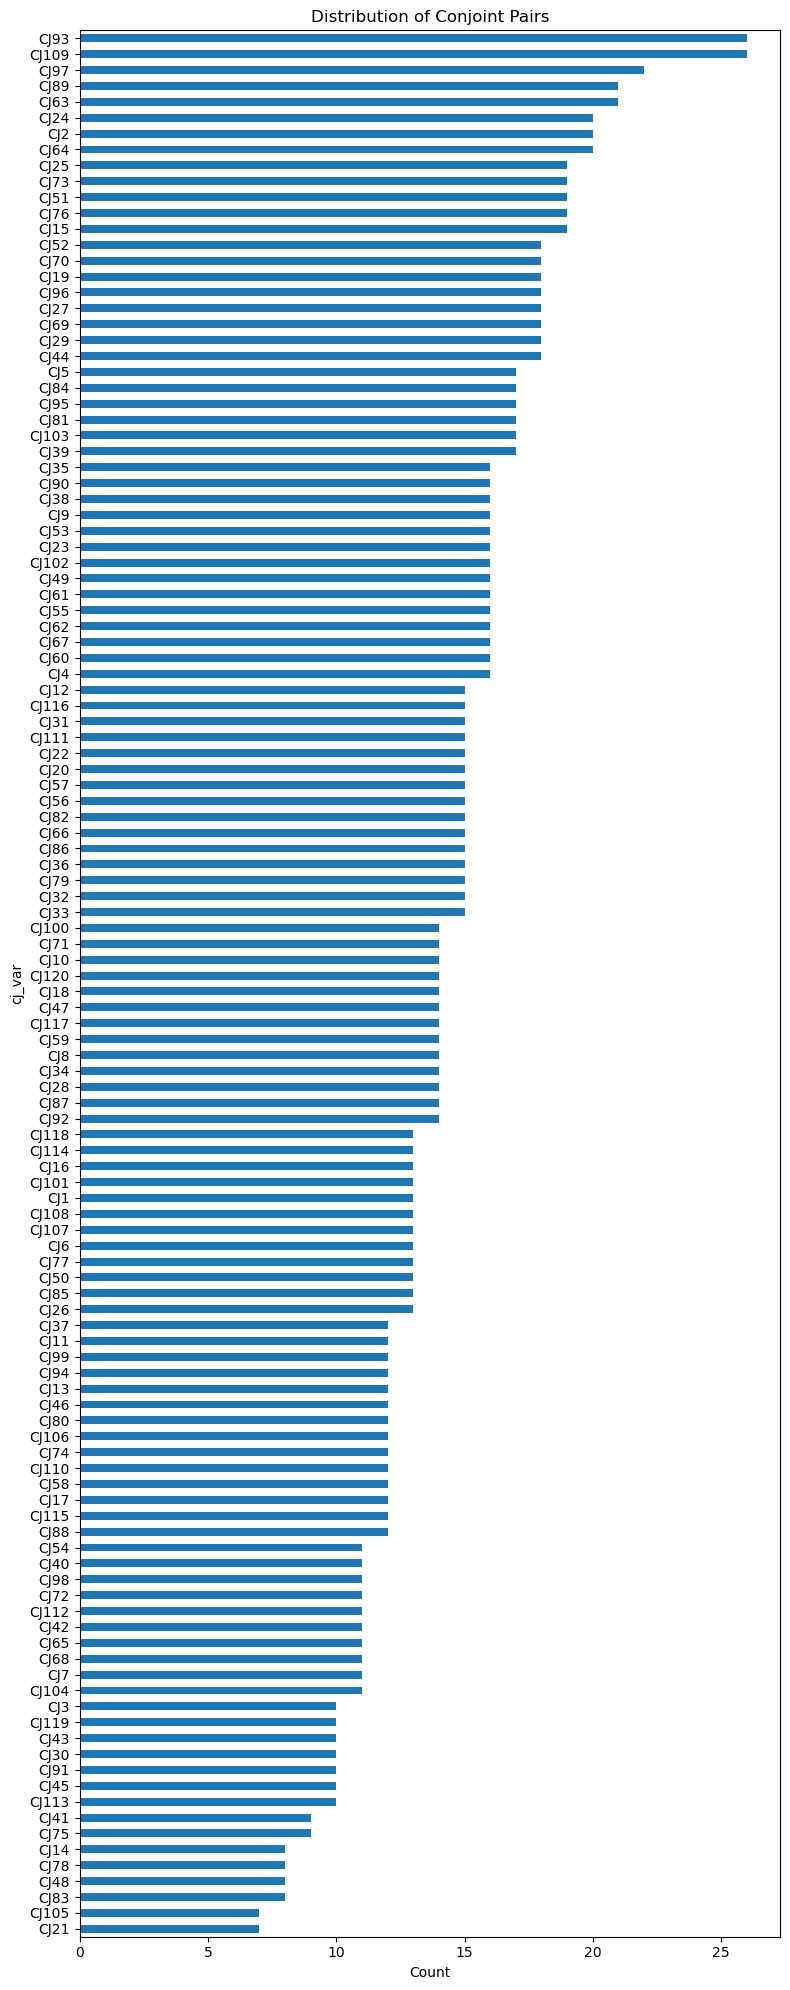

In [385]:
counts = long_df['cj_var'].value_counts().sort_values()

plt.figure(figsize=(8, 20))

counts.plot(kind='barh')

plt.xlabel('Count')

plt.ylabel('cj_var')

plt.title('Distribution of Conjoint Pairs')

plt.tight_layout()

plt.show()

In [386]:
long_df['cj_var'] = long_df['cj_var'].map(dict(var_to_encod))

In [387]:
len(long_df['cj_var'].unique())

120

In [388]:
choice_df = long_df.copy()

# rename for clarity

choice_df = choice_df.rename(columns={'pair_value': 'choice'})

# split pair string into two candidate profiles

choice_df[['profile_1', 'profile_2']] = choice_df['cj_var'].str.split('/', expand=True)

# create candidate 1 rows

cand1 = choice_df.copy()

cand1['candidate'] = 1

cand1['profile'] = cand1['profile_1']

cand1['outcome'] = (cand1['choice'] == 1).astype(int)

# create candidate 2 rows

cand2 = choice_df.copy()

cand2['candidate'] = 2

cand2['profile'] = cand2['profile_2']

cand2['outcome'] = (cand2['choice'] == 2).astype(int)

# stack them

long_choice_df = pd.concat([cand1, cand2], ignore_index=True)

# optional: drop intermediate columns

long_choice_df = long_choice_df.drop(columns=['profile_1', 'profile_2'])

# reorder columns

front_cols = ['respondent_id', 'task_num', 'cj_var', 'candidate', 'profile', 'choice', 'outcome']

other_cols = [c for c in long_choice_df.columns if c not in front_cols]

long_choice_df = long_choice_df[front_cols + other_cols]

# sort nicely

long_choice_df = long_choice_df.sort_values(

    ['respondent_id', 'task_num', 'candidate']

).reset_index(drop=True)

In [389]:
long_choice_df['cj_var'].value_counts()

cj_var
C2E1F1S2/C2E1F1S1    52
C2E1F2S1/C2E2F2S1    52
C2E2F1S2/C2E1F1S1    44
C1E2F2S2/C2E2F1S1    42
C2E2F1S2/C1E2F1S1    42
                     ..
C1E1F1S1/C2E2F2S1    16
C2E2F2S1/C1E2F2S1    16
C1E2F2S1/C2E1F1S2    16
C2E1F1S2/C2E2F2S2    14
C1E2F2S2/C1E1F1S2    14
Name: count, Length: 120, dtype: int64

In [390]:
tmp = long_choice_df['profile'].str.extract(r'C([12])E([12])F([12])S([12])').astype(int)

long_choice_df['collaboration_illiberal'] = (tmp[0] == 2).astype(int)
long_choice_df['economy_illiberal'] = (tmp[1] == 2).astype(int)
long_choice_df['FreedomSpeech_illiberal'] = (tmp[2] == 2).astype(int)
long_choice_df['Surveillance_illiberal'] = (tmp[3] == 2).astype(int)

In [391]:
long_choice_df

,respondent_id,task_num,cj_var,candidate,profile,choice,outcome,status,invitation,relevance,...,Social_Media_Trust_Clean_c,Messengers_Trust_Clean_c,Radio_Trust_Clean_c,Interpersonal_Communication_Trust_Clean_c,Newspapers_Trust_Clean_c,Magazines_Trust_Clean_c,collaboration_illiberal,economy_illiberal,FreedomSpeech_illiberal,Surveillance_illiberal
0,11,1,C2E1F2S1/C2E2F1S1,1,C2E1F2S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,0,1,0
1,11,1,C2E1F2S1/C2E2F1S1,2,C2E2F1S1,1,0,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,1,0,0
2,11,2,C1E1F2S1/C1E1F1S2,1,C1E1F2S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,0,0,1,0
3,11,2,C1E1F2S1/C1E1F1S2,2,C1E1F1S2,1,0,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,0,0,0,1
4,11,3,C2E1F1S1/C1E1F1S2,1,C2E1F1S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3427,977,2,C1E1F1S2/C2E1F2S1,2,C2E1F2S1,1,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,1,0,1,0
3428,977,3,C1E2F2S1/C1E1F2S1,1,C1E2F2S1,2,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,1,1,0
3429,977,3,C1E2F2S1/C1E1F2S1,2,C1E1F2S1,2,1,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,0,1,0
3430,977,4,C1E2F2S2/C2E2F1S2,1,C1E2F2S2,2,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,1,1,1


In [392]:
print(df.columns[df.columns.duplicated()])

Index([], dtype='object')


In [393]:
import statsmodels.formula.api as smf

In [394]:
amce_model = smf.ols('outcome ~ collaboration_illiberal + economy_illiberal + FreedomSpeech_illiberal + Surveillance_illiberal' , data=long_choice_df).fit(cov_type='cluster', cov_kwds={'groups': long_choice_df['respondent_id']})

In [395]:
amce_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     33.68
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.94e-24
Time:                        14:59:00   Log-Likelihood:                -2403.0
No. Observations:                3432   AIC:                             4816.
Df Residuals:                    3427   BIC:                             4847.
Df Model:                           4                                         
Covariance Type:              cluster                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.6347      0.021     30.586      0.000       0.594       0.675
collaboration_illiberal    -0.0026      0.019     -0.134      0.893      -0.041       0.035
economy_illiberal           0.0365      0.018      1.981      0.048       0.000       0.073
FreedomSpeech_illiberal    -0.1684      0.019     -8.830      0.000      -0.206      -0.131
Surveillance_illiberal     -0.1438      0.019     -7.647      0.000      -0.181      -0.107
==============================================================================
Omnibus:                    13850.638   Durbin-Watson:                   3.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              462.483
Skew:                          -0.002   Prob(JB):                    3.74e-101
Kurtosis:                       1.202   Cond. No.                         4.27
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [396]:
long_choice_df

,respondent_id,task_num,cj_var,candidate,profile,choice,outcome,status,invitation,relevance,...,Social_Media_Trust_Clean_c,Messengers_Trust_Clean_c,Radio_Trust_Clean_c,Interpersonal_Communication_Trust_Clean_c,Newspapers_Trust_Clean_c,Magazines_Trust_Clean_c,collaboration_illiberal,economy_illiberal,FreedomSpeech_illiberal,Surveillance_illiberal
0,11,1,C2E1F2S1/C2E2F1S1,1,C2E1F2S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,0,1,0
1,11,1,C2E1F2S1/C2E2F1S1,2,C2E2F1S1,1,0,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,1,0,0
2,11,2,C1E1F2S1/C1E1F1S2,1,C1E1F2S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,0,0,1,0
3,11,2,C1E1F2S1/C1E1F1S2,2,C1E1F1S2,1,0,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,0,0,0,1
4,11,3,C2E1F1S1/C1E1F1S2,1,C2E1F1S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3427,977,2,C1E1F1S2/C2E1F2S1,2,C2E1F2S1,1,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,1,0,1,0
3428,977,3,C1E2F2S1/C1E1F2S1,1,C1E2F2S1,2,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,1,1,0
3429,977,3,C1E2F2S1/C1E1F2S1,2,C1E1F2S1,2,1,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,0,1,0
3430,977,4,C1E2F2S2/C2E2F1S2,1,C1E2F2S2,2,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,1,1,1


In [397]:
len(long_choice_df['cj_var'].unique())

120

In [398]:
factor_cols = [
    "collaboration_illiberal",
    "economy_illiberal",
    "FreedomSpeech_illiberal",
    "Surveillance_illiberal"
]

for col in factor_cols:
    print("\n", col)
    print(long_choice_df[col].value_counts(dropna=False).sort_index())
    print(long_choice_df[col].value_counts(normalize=True, dropna=False).sort_index())


 collaboration_illiberal
collaboration_illiberal
0    1711
1    1721
Name: count, dtype: int64
collaboration_illiberal
0    0.498543
1    0.501457
Name: proportion, dtype: float64

 economy_illiberal
economy_illiberal
0    1713
1    1719
Name: count, dtype: int64
economy_illiberal
0    0.499126
1    0.500874
Name: proportion, dtype: float64

 FreedomSpeech_illiberal
FreedomSpeech_illiberal
0    1789
1    1643
Name: count, dtype: int64
FreedomSpeech_illiberal
0    0.52127
1    0.47873
Name: proportion, dtype: float64

 Surveillance_illiberal
Surveillance_illiberal
0    1735
1    1697
Name: count, dtype: int64
Surveillance_illiberal
0    0.505536
1    0.494464
Name: proportion, dtype: float64


In [399]:
from scipy.stats import chisquare

factor_cols = [
    "collaboration_illiberal",
    "economy_illiberal",
    "FreedomSpeech_illiberal",
    "Surveillance_illiberal"
]

for col in factor_cols:
    counts = long_choice_df[col].value_counts().sort_index()
    expected = [len(long_choice_df) / 2] * 2
    chi2, p = chisquare(counts, f_exp=expected)

    print(col)
    print("counts:", counts.to_dict())
    print("chi2:", round(chi2, 3), "p:", round(p, 4))
    print()

collaboration_illiberal
counts: {0: 1711, 1: 1721}
chi2: 0.029 p: 0.8645

economy_illiberal
counts: {0: 1713, 1: 1719}
chi2: 0.01 p: 0.9184

FreedomSpeech_illiberal
counts: {0: 1789, 1: 1643}
chi2: 6.211 p: 0.0127

Surveillance_illiberal
counts: {0: 1735, 1: 1697}
chi2: 0.421 p: 0.5166



In [400]:
import pandas as pd
from itertools import combinations

factor_cols = [
    "collaboration_illiberal",
    "economy_illiberal",
    "FreedomSpeech_illiberal",
    "Surveillance_illiberal"
]

for col1, col2 in combinations(factor_cols, 2):
    print(f"\n=== {col1} × {col2} ===")
    
    tab = pd.crosstab(
        long_choice_df[col1],
        long_choice_df[col2],
        normalize="all"
    )
    
    print(tab)


=== collaboration_illiberal × economy_illiberal ===
economy_illiberal               0         1
collaboration_illiberal                    
0                        0.245047  0.253497
1                        0.254079  0.247378

=== collaboration_illiberal × FreedomSpeech_illiberal ===
FreedomSpeech_illiberal         0         1
collaboration_illiberal                    
0                        0.259033  0.239510
1                        0.262238  0.239219

=== collaboration_illiberal × Surveillance_illiberal ===
Surveillance_illiberal          0         1
collaboration_illiberal                    
0                        0.248543  0.250000
1                        0.256993  0.244464

=== economy_illiberal × FreedomSpeech_illiberal ===
FreedomSpeech_illiberal         0         1
economy_illiberal                          
0                        0.254953  0.244172
1                        0.266317  0.234557

=== economy_illiberal × Surveillance_illiberal ===
Surveillance_illibera

In [401]:
model = smf.ols(
    'outcome ~ collaboration_illiberal + economy_illiberal + FreedomSpeech_illiberal + Surveillance_illiberal',
    data=long_choice_df
).fit(
    cov_type='cluster',
    cov_kwds={'groups': long_choice_df['respondent_id']}
)

In [402]:
for c in long_choice_df.columns:
    print(c)

respondent_id
task_num
cj_var
candidate
profile
choice
outcome
status
invitation
relevance
lurker
recnum
code
testdata
itime
Q1
Q3a
Q5a
Q5b
Q5c
Q5d
Q5e
Q5f
Q6a
Q6b
Q6c
Q6d
Q6e
Q6f
Q6g
Q6h
Q7a
Q7b
Q7c
Q7d
Q7e
Q7f
Q7g
Q6_2a
Q6_2b
Q6_2c
Q99a
Q99b
Q99c
Q99d
Q99e
Q99f
Q99g
Q8a
Q8b
Q8c
Q8d
Q8e
Q8f
Q8g
Q8h
Q8i
Q8j
Q9a
Q9b
Q9c
Q9d
Q10a
Q10b
Q10c
Q11a
Q11b
Q11c
Q11d
Q11e
Q11f
Q11g
Q11h
Q12a
Q12b
Q12c
Q12d
Q12e
Q12f
Q12g
Q12h
Q14a
Q14b
Q14c
Q14d
Q15a
Q15b
Q15c
Q15d
Q15e
Q15f
Q15g
Q15h
Q15i
Q37
Q38
Q38_3_text
Q39
Q39_2_text
Q40
Q41a
Q41b
Q42
random_15608146
random_15608168
random_15614862
random_15570229
random_15570244
random_15578299
random_15578300
random_15570238
random_15570670
random_15570669
random_15614960
random_15614966
random_15628367
random_15628372
random_15628374
random_15628376
random_15628378
random_15628380
random_1366752
t_insert
t_edit
date_0
date_1
date_2
date_3
date_4
date_5
date_6
date_7
date_8
date_9
date_10
date_11
date_12
date_13
date_14
date_15
date_16
date_17
date_18
da

In [403]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     33.68
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.94e-24
Time:                        14:59:30   Log-Likelihood:                -2403.0
No. Observations:                3432   AIC:                             4816.
Df Residuals:                    3427   BIC:                             4847.
Df Model:                           4                                         
Covariance Type:              cluster                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.6347      0.021     30.586      0.000       0.594       0.675
collaboration_illiberal    -0.0026      0.019     -0.134      0.893      -0.041       0.035
economy_illiberal           0.0365      0.018      1.981      0.048       0.000       0.073
FreedomSpeech_illiberal    -0.1684      0.019     -8.830      0.000      -0.206      -0.131
Surveillance_illiberal     -0.1438      0.019     -7.647      0.000      -0.181      -0.107
==============================================================================
Omnibus:                    13850.638   Durbin-Watson:                   3.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              462.483
Skew:                          -0.002   Prob(JB):                    3.74e-101
Kurtosis:                       1.202   Cond. No.                         4.27
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [404]:
for c in long_choice_df.columns:
    print(c)

respondent_id
task_num
cj_var
candidate
profile
choice
outcome
status
invitation
relevance
lurker
recnum
code
testdata
itime
Q1
Q3a
Q5a
Q5b
Q5c
Q5d
Q5e
Q5f
Q6a
Q6b
Q6c
Q6d
Q6e
Q6f
Q6g
Q6h
Q7a
Q7b
Q7c
Q7d
Q7e
Q7f
Q7g
Q6_2a
Q6_2b
Q6_2c
Q99a
Q99b
Q99c
Q99d
Q99e
Q99f
Q99g
Q8a
Q8b
Q8c
Q8d
Q8e
Q8f
Q8g
Q8h
Q8i
Q8j
Q9a
Q9b
Q9c
Q9d
Q10a
Q10b
Q10c
Q11a
Q11b
Q11c
Q11d
Q11e
Q11f
Q11g
Q11h
Q12a
Q12b
Q12c
Q12d
Q12e
Q12f
Q12g
Q12h
Q14a
Q14b
Q14c
Q14d
Q15a
Q15b
Q15c
Q15d
Q15e
Q15f
Q15g
Q15h
Q15i
Q37
Q38
Q38_3_text
Q39
Q39_2_text
Q40
Q41a
Q41b
Q42
random_15608146
random_15608168
random_15614862
random_15570229
random_15570244
random_15578299
random_15578300
random_15570238
random_15570670
random_15570669
random_15614960
random_15614966
random_15628367
random_15628372
random_15628374
random_15628376
random_15628378
random_15628380
random_1366752
t_insert
t_edit
date_0
date_1
date_2
date_3
date_4
date_5
date_6
date_7
date_8
date_9
date_10
date_11
date_12
date_13
date_14
date_15
date_16
date_17
date_18
da

In [405]:
model = smf.ols(
    'outcome ~ collaboration_illiberal + economy_illiberal + FreedomSpeech_illiberal + Surveillance_illiberal',
    data=long_choice_df
).fit(
    cov_type='cluster',
    cov_kwds={'groups': long_choice_df['respondent_id']}
)

In [406]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     33.68
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.94e-24
Time:                        14:59:30   Log-Likelihood:                -2403.0
No. Observations:                3432   AIC:                             4816.
Df Residuals:                    3427   BIC:                             4847.
Df Model:                           4                                         
Covariance Type:              cluster                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.6347      0.021     30.586      0.000       0.594       0.675
collaboration_illiberal    -0.0026      0.019     -0.134      0.893      -0.041       0.035
economy_illiberal           0.0365      0.018      1.981      0.048       0.000       0.073
FreedomSpeech_illiberal    -0.1684      0.019     -8.830      0.000      -0.206      -0.131
Surveillance_illiberal     -0.1438      0.019     -7.647      0.000      -0.181      -0.107
==============================================================================
Omnibus:                    13850.638   Durbin-Watson:                   3.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              462.483
Skew:                          -0.002   Prob(JB):                    3.74e-101
Kurtosis:                       1.202   Cond. No.                         4.27
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [407]:
long_choice_df['Q37'] = long_choice_df['Q37'].astype(int)
long_choice_df['Q40'] = long_choice_df['Q40'].astype(int)
long_choice_df['Q41a'] = long_choice_df['Q41a'].astype(int)
long_choice_df['Q41b'] = long_choice_df['Q41b'].astype(int)
long_choice_df['Q42'] = long_choice_df['Q42'].astype(int)

In [408]:
# count how many "2"s in the profile
twos = long_choice_df['profile'].str.count('2')

long_choice_df['profile_heterogeneity'] = (
    twos.map({
        0: 1,  # all 1s
        4: 1,  # (optional) all 2s, same logic as homogeneous
        1: 2,
        3: 2,
        2: 3
    })
)

In [409]:
long_choice_df['Q37'].min()

18

In [410]:
long_choice_df['Q39'].value_counts()

Q39
1    3432
Name: count, dtype: int64

In [411]:
long_choice_df.to_csv('conjoint_df.csv')

In [314]:
long_choice_df

,respondent_id,task_num,cj_var,candidate,profile,choice,outcome,status,invitation,relevance,...,Social_Media_Trust_Clean_c,Messengers_Trust_Clean_c,Radio_Trust_Clean_c,Interpersonal_Communication_Trust_Clean_c,Newspapers_Trust_Clean_c,Magazines_Trust_Clean_c,collaboration_illiberal,economy_illiberal,FreedomSpeech_illiberal,Surveillance_illiberal
0,11,1,C2E1F2S1/C2E2F1S1,1,C2E1F2S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,0,1,0
1,11,1,C2E1F2S1/C2E2F1S1,2,C2E2F1S1,1,0,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,1,0,0
2,11,2,C1E1F2S1/C1E1F1S2,1,C1E1F2S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,0,0,1,0
3,11,2,C1E1F2S1/C1E1F1S2,2,C1E1F1S2,1,0,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,0,0,0,1
4,11,3,C2E1F1S1/C1E1F1S2,1,C2E1F1S1,1,1,6,0,1,...,0.881773,1.72973,1.280453,-0.223558,-0.52924,-0.39521,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3427,977,2,C1E1F1S2/C2E1F2S1,2,C2E1F2S1,1,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,1,0,1,0
3428,977,3,C1E2F2S1/C1E1F2S1,1,C1E2F2S1,2,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,1,1,0
3429,977,3,C1E2F2S1/C1E1F2S1,2,C1E1F2S1,2,1,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,0,1,0
3430,977,4,C1E2F2S2/C2E2F1S2,1,C1E2F2S2,2,0,6,0,1,...,0.881773,-1.27027,-1.719547,0.776442,-0.52924,-0.39521,0,1,1,1
